# ReLU-Tune Training Run

Notebook for clone, install, train, evaluate, measure sparsity, and print final metrics.

### Downloading the Repo

In [1]:
import os
from getpass import getpass
# getpass keeps tokens out of notebook cell output.

REPO_URL = "https://github.com/gingerfocus/ReLU-Tune.git"
REPO_REF = "main"

!git clone $REPO_URL ReLU-Tune
%cd ReLU-Tune
!git fetch origin
!git checkout $REPO_REF

Cloning into 'ReLU-Tune'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 48 (delta 12), reused 43 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 90.89 KiB | 10.10 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/ReLU-Tune
Already on 'main'
Your branch is up to date with 'origin/main'.


### Setting up Secrets

In [3]:
## For Google Colab

from google.colab import userdata
HF_TOKEN = userdata.get("HF")
os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN

## Optional wandb setup. Leave disabled unless you explicitly want it.
os.environ["WANDB_ENABLED"] = "false" # "false"
if os.environ.get("WANDB_ENABLED") == "true":
  WANDB_API_KEY = userdata.get("WANDB") # None
  os.environ["WANDB_API_KEY"] = WANDB_API_KEY


In [ ]:
# # For Other Cloud Services
# # Set the tokens in the environment
# HF_TOKEN = os.environ.get("HF_TOKEN")
# if not HF_TOKEN:
#     HF_TOKEN = getpass("HF_TOKEN: ").strip()

# os.environ["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN

# os.environ["WANDB_ENABLED"] = "false" # "true"
# if os.environ.get("WANDB_ENABLED") == "true":
#     # Optional wandb setup. Leave disabled unless you explicitly want it.
#     if not os.environ.get("WANDB_TOKEN"):
#         WANDB_API_KEY = getpass("WANDB_API_KEY: ").strip()
#     else:
#         WANDB_API_KEY = os.environ.get("WANDB_TOKEN")

#     os.environ["WANDB_API_KEY"] = WANDB_API_KEY


### Setting up the repo

In [4]:
!pip uninstall -y torchao # for google colab
!pip install -r requirements.txt

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 14.0 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=0d09ce5c7d3ba65c2f700c1340441eef85a202cf20cb9d9d3d7388f475ff63da
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
  Created wheel for sqlitedict: filename=sqlitedict-2.1.0-py3-none-any.whl size=16862 sha256=ad6e8

## Config

In [5]:
# Default debug preset for learning the workflow.
# Switch to configs/train_llama31_8b.yaml for the full 8B run.
TRAIN_CONFIG = "configs/train_llama32_1b_debug.yaml"
EVAL_CONFIG = "configs/evaluation.yaml"
SPARSITY_CONFIG = "configs/sparsity.yaml"
USE_TIMESTAMP = True

In [6]:
from datetime import datetime
from pathlib import Path

import yaml

train_config_path = Path(TRAIN_CONFIG)
runtime_train_config_path = Path("configs/train_runtime.yaml")
train_config = yaml.safe_load(train_config_path.read_text(encoding="utf-8"))

if USE_TIMESTAMP:
    train_config["run_name"] = f"{train_config['run_name']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

train_config["logging"]["wandb"]["enabled"] = os.environ.get("WANDB_ENABLED")
runtime_train_config_path.write_text(
    yaml.safe_dump(train_config, sort_keys=False),
    encoding="utf-8",
)

BASE_MODEL = train_config["model_id"]
RUN_DIR = str(Path(train_config.get("output_root", "./runs")) / train_config["run_name"])

print("Base model:", BASE_MODEL)
print("Run dir:", RUN_DIR)


Base model: meta-llama/Llama-3.2-1B
Run dir: runs/llama32_1b_relu_debug_20260624_184730


# Layer Sweep (Optional)
Finds best layers to ReLU-fy and updates the config

Before training all 16 layers, run a quick sweep to identify which 8 layers adapt best to ReLU.
Each layer is ReLU-fied individually, trained for 30 steps, and ranked by train loss, validation loss, and sparsity.

In [ ]:
!python scripts/relu_layer_sweep.py \
    --config configs/train_llama32_1b_debug.yaml \
    --steps-per-layer 30 \
    --top-k 8 \
    --measure-sparsity \
    --output {RUN_DIR}/layer_sweep.json

In [ ]:
# Load sweep results and update the training config to use only the top 8 layers.
import json
from pathlib import Path
sweep_path = Path(RUN_DIR) / "layer_sweep.json"
sweep = json.loads(sweep_path.read_text(encoding="utf-8"))
selected_layers = sweep["selected_layers"]
print(f"Selected layers: {selected_layers}")
# Update the runtime config to use partial ReLU-fication with the selected layers
train_config["activation"]["layer_mode"] = "partial"
train_config["activation"]["layer_indices"] = selected_layers
runtime_train_config_path.write_text(
    yaml.safe_dump(train_config, sort_keys=False),
    encoding="utf-8",
)
print(f"Updated config saved to {runtime_train_config_path}")

In [ ]:
# Display the per-layer sweep results as a table.
import pandas as pd
from IPython.display import display
df = pd.DataFrame(sweep["results"])
df = df.sort_values("layer")
display(df)

## Training

In [7]:
!python scripts/train_staged_lora.py --config {runtime_train_config_path} --run-dir {RUN_DIR}

[Runtime] Enabling Transformers checkpoint resume compatibility. This relaxes safe deserialization checks so local training checkpoints can be resumed. Only resume checkpoints you trust.
ReLU-Tune staged training
Model: meta-llama/Llama-3.2-1B
Activation: relu
Total steps: 60
Stage size: 20
Num devices: 1
config.json: 100%|##########| 843/843 [00:00<00:00, 3.29MB/s]
tokenizer_config.json: 50.5kB [00:00, 64.9MB/s]
tokenizer.json: 9.09MB [00:00, 24.3MB/s]
special_tokens_map.json: 100%|##########| 301/301 [00:00<00:00, 1.62MB/s]
README.md: 9.04kB [00:00, 225kB/s]
Saving the dataset (1/1 shards): 100%|##########| 130/130 [00:00<00:00, 30255.22 examples/s]

[Stage 1] 0 -> 20
[Stage 1] Train sequences: 80
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors: 100%|##########| 2.47G/2.47G [00:12<00:00, 191MB/s]
[Model Load] flash_attention_2 unavailable for meta-llama/Llama-3.2-1B; falling back to eager attention. Original error: FlashAttention2 has been toggled on, but it canno

In [8]:
!python scripts/plot_run_metrics.py --run-dir {RUN_DIR}

Saved plots to runs/llama32_1b_relu_debug_20260624_184730/plots


train_loss.png


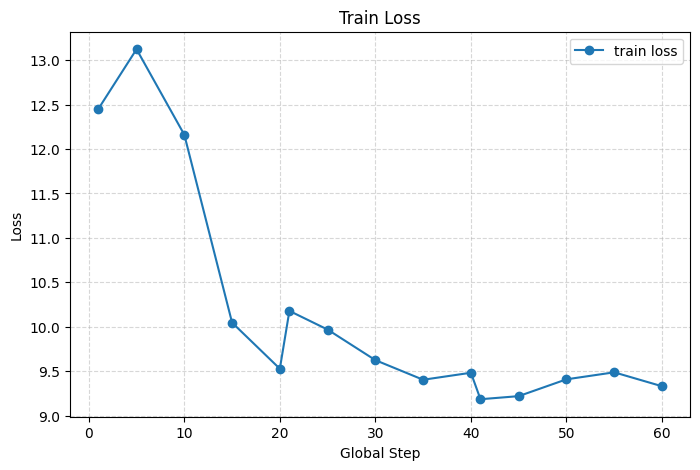

loss_overlay.png


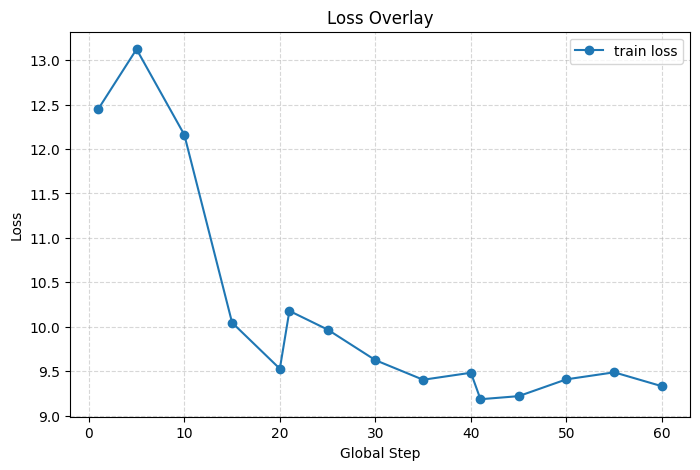

lr.png


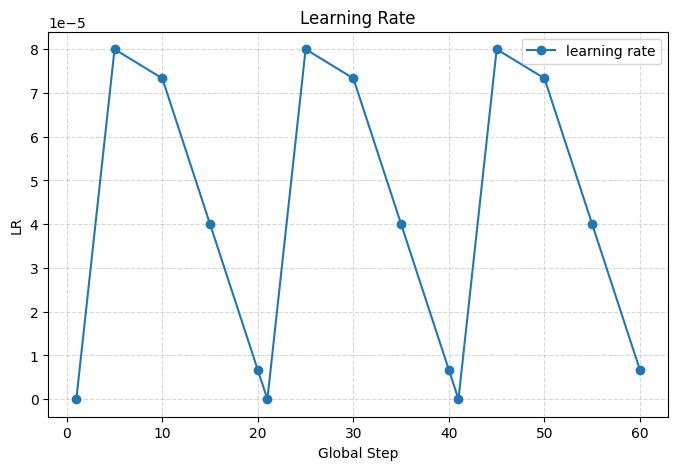

In [9]:
from IPython.display import Image, display
from pathlib import Path

plots_dir = Path(RUN_DIR) / "plots"
for name in ["train_loss.png", "val_loss.png", "loss_overlay.png", "lr.png"]:
    path = plots_dir / name
    if path.exists():
        print(name)
        display(Image(filename=str(path)))


## Evaluation

In [10]:
!python scripts/evaluate.py --config {EVAL_CONFIG} --model-path {RUN_DIR}/final_merged --output-dir {RUN_DIR}/final_eval

`torch_dtype` is deprecated! Use `dtype` instead!
[Model Load] flash_attention_2 unavailable for runs/llama32_1b_relu_debug_20260624_184730/final_merged; falling back to eager attention. Original error: FlashAttention2 has been toggled on, but it cannot be used due to the following error: the package flash_attn seems to be not installed. Please refer to the documentation of https://huggingface.co/docs/transformers/perf_infer_gpu_one#flashattention-2 to install Flash Attention 2.
Loading weights: 100% 146/146 [00:00<00:00, 1355.72it/s, Materializing param=model.norm.weight]

Model summary
--------------------------------------------------
Layer      | Activation                    
--------------------------------------------------
0          | ReLU                          
1          | ReLU                          
2          | ReLU                          
3          | ReLU                          
4          | ReLU                          
5          | ReLU                      

In [11]:
!python scripts/measure_sparsity.py --config {SPARSITY_CONFIG} --model-path {RUN_DIR}/final_merged --output-path {RUN_DIR}/final_eval/prefill_sparsity.json

`torch_dtype` is deprecated! Use `dtype` instead!
[Model Load] flash_attention_2 unavailable for runs/llama32_1b_relu_debug_20260624_184730/final_merged; falling back to eager attention. Original error: FlashAttention2 has been toggled on, but it cannot be used due to the following error: the package flash_attn seems to be not installed. Please refer to the documentation of https://huggingface.co/docs/transformers/perf_infer_gpu_one#flashattention-2 to install Flash Attention 2.
Loading weights: 100% 146/146 [00:00<00:00, 1324.44it/s, Materializing param=model.norm.weight]
README.md: 41.1kB [00:00, 9.42MB/s]
Resolving data files: 100% 1024/1024 [00:00<00:00, 17340.09it/s]
Resolving data files: 100% 1024/1024 [00:00<00:00, 27609.72it/s]
[Sparsity] Saved to runs/llama32_1b_relu_debug_20260624_184730/final_eval/prefill_sparsity.json
[Sparsity] Average sparsity: 62.39%


## [Optional] Baseline Evaluation

In [12]:
!python scripts/evaluate.py --config {EVAL_CONFIG} --base-model {BASE_MODEL} --output-dir {RUN_DIR}/baseline_eval

`torch_dtype` is deprecated! Use `dtype` instead!
[Model Load] flash_attention_2 unavailable for meta-llama/Llama-3.2-1B; falling back to eager attention. Original error: FlashAttention2 has been toggled on, but it cannot be used due to the following error: the package flash_attn seems to be not installed. Please refer to the documentation of https://huggingface.co/docs/transformers/perf_infer_gpu_one#flashattention-2 to install Flash Attention 2.
Loading weights: 100% 146/146 [00:00<00:00, 506.04it/s, Materializing param=model.norm.weight]

Model summary
--------------------------------------------------
Layer      | Activation                    
--------------------------------------------------
0          | SiLUActivation                
1          | SiLUActivation                
2          | SiLUActivation                
3          | SiLUActivation                
4          | SiLUActivation                
5          | SiLUActivation                
6          | SiLUActivation 

## [Optional] Baseline Sparsity

In [13]:
!python scripts/measure_sparsity.py --config {SPARSITY_CONFIG} --base-model {BASE_MODEL} --output-path {RUN_DIR}/baseline_eval/prefill_sparsity.json

`torch_dtype` is deprecated! Use `dtype` instead!
[Model Load] flash_attention_2 unavailable for meta-llama/Llama-3.2-1B; falling back to eager attention. Original error: FlashAttention2 has been toggled on, but it cannot be used due to the following error: the package flash_attn seems to be not installed. Please refer to the documentation of https://huggingface.co/docs/transformers/perf_infer_gpu_one#flashattention-2 to install Flash Attention 2.
Loading weights: 100% 146/146 [00:00<00:00, 1653.89it/s, Materializing param=model.norm.weight]
Resolving data files: 100% 1024/1024 [00:00<00:00, 22649.91it/s]
Resolving data files: 100% 1024/1024 [00:00<00:00, 19390.81it/s]
[Sparsity] Saved to runs/llama32_1b_relu_debug_20260624_184730/baseline_eval/prefill_sparsity.json
[Sparsity] Average sparsity: 0.00%


## Summary

In [14]:
import json
from pathlib import Path

run_dir = Path(RUN_DIR)
def latest_json(directory):
    files = sorted(directory.glob("evaluation_*.json"))
    return files[-1] if files else None

def latest_metric(metric_name):
    latest = None
    for path in sorted(run_dir.glob("stage_*/metrics.json")):
        logs = json.loads(path.read_text(encoding="utf-8"))
        for entry in logs:
            if metric_name in entry:
                latest = entry
    return latest

def summarize_perplexity(payload):
    summary = {}
    for name, value in payload.items():
        if isinstance(value, dict) and "perplexity" in value:
            summary[name] = round(value["perplexity"], 4)
    return summary

def summarize_sparsity(path):
    if not path.exists():
        return None
    payload = json.loads(path.read_text(encoding="utf-8"))
    summary = payload.get("summary", {})
    average = summary.get("average_sparsity")
    if average is None:
        return None
    return {
        "average_sparsity_percent": round(average, 4),
        "measured_layers": summary.get("measured_layers"),
    }

last_train = latest_metric("loss")
last_eval = latest_metric("eval_loss")

print(f"Run dir: {run_dir}")

if last_train:
    print(f"Final train loss: {last_train['loss']:.4f} (step {last_train.get('step', 'n/a')})")
else:
    print("Final train loss: not found")

if last_eval:
    print(f"Final val loss: {last_eval['eval_loss']:.4f} (step {last_eval.get('step', 'n/a')})")
else:
    print("Final val loss: not found")

merged_eval_path = latest_json(run_dir / "final_eval")
if merged_eval_path:
    merged_eval = json.loads(merged_eval_path.read_text(encoding="utf-8"))
    print("\nMerged model outputs:")
    print(f"- evaluation file: {merged_eval_path.name}")
    benchmark_summary = merged_eval.get("benchmarks", {}).get("summary")
    if benchmark_summary:
        print(f"- benchmark summary: {benchmark_summary}")
    perplexity_summary = summarize_perplexity(merged_eval.get("perplexity", {}))
    if perplexity_summary:
        print(f"- perplexity: {perplexity_summary}")
else:
    print("\nMerged model outputs: not found")

merged_sparsity = summarize_sparsity(run_dir / "final_eval" / "prefill_sparsity.json")
if merged_sparsity:
    print(f"- sparsity: {merged_sparsity}")

baseline_eval_path = latest_json(run_dir / "baseline_eval")
baseline_sparsity = summarize_sparsity(run_dir / "baseline_eval" / "prefill_sparsity.json")
if baseline_eval_path or baseline_sparsity:
    print("\nOptional baseline outputs found in baseline_eval/.")


Run dir: runs/llama32_1b_relu_debug_20260624_184730
Final train loss: 9.3305 (step 20)
Final val loss: not found

Merged model outputs:
- evaluation file: evaluation_20260624_205541.json
- benchmark summary: {'piqa': 0.5484221980413493, 'openbookqa': 0.27, 'sciq': 0.254, 'winogrande': 0.4877663772691397, 'hellaswag': 0.2650866361282613, 'arc_easy': 0.2558922558922559, 'boolq': 0.40244648318042814}
- perplexity: {'wikitext2': 15821.3877, 'refinedweb': 13116.1279}
- sparsity: {'average_sparsity_percent': 62.386, 'measured_layers': 16}

Optional baseline outputs found in baseline_eval/.


### Export Results
Mounts Google Drive and appends results to a persistant file given a name for the run.

In [15]:
from google.colab import drive
import pandas as pd
import os

run_name = input("Enter a name for this run: ")
if not run_name:
  print("You need to give this run a name to record meaningful results!!!")
  raise SystemExit("Stopping cell execution")

# Mount drive
drive.mount('/content/drive')

# Define the tracker path on Drive
DRIVE_TRACKER_PATH = '/content/drive/MyDrive/relu_tune_experiments.csv'

# Prepare data for current run
run_data = {
    'run_name': Path(RUN_DIR).name,
    'base_model': BASE_MODEL,
    'train_loss': last_train['loss'] if last_train else None,
    'avg_sparsity': merged_sparsity['average_sparsity_percent'] if merged_sparsity else None,
    **benchmark_summary,
    **perplexity_summary
}

df_current = pd.DataFrame([run_data])

# Append to existing CSV or create new
if os.path.exists(DRIVE_TRACKER_PATH):
    df_existing = pd.read_csv(DRIVE_TRACKER_PATH)
    df_final = pd.concat([df_existing, df_current], ignore_index=True)
else:
    df_final = df_current

df_final.to_csv(DRIVE_TRACKER_PATH, index=False)
print(f"Results saved to {DRIVE_TRACKER_PATH}")
display(df_current)

Enter a name for this run: all-layers-debug
Mounted at /content/drive
Results saved to /content/drive/MyDrive/relu_tune_experiments.csv


,run_name,base_model,train_loss,avg_sparsity,piqa,openbookqa,sciq,winogrande,hellaswag,arc_easy,boolq,wikitext2,refinedweb
0,llama32_1b_relu_debug_20260624_184730,meta-llama/Llama-3.2-1B,9.330481,62.386,0.548422,0.27,0.254,0.487766,0.265087,0.255892,0.402446,15821.3877,13116.1279
